In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# ---------- Load & sample ----------
DATA_PATH = "data/amazon_dsld_merged.csv"
SAMPLE_FRAC = 0.10  # 10 % sample for fast EDA
SEED = 42

df_full = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset: {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")

df = df_full.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)
print(f"Sample ({SAMPLE_FRAC:.0%}): {df.shape[0]:,} rows × {df.shape[1]} cols")

del df_full  # free memory

Full dataset: 218,678 rows × 32 cols
Sample (10%): 21,868 rows × 32 cols


## 1 — Basic Data Overview

In [2]:
# Quick look at the first few rows
df.head(3)

,parent_asin,asin,review_rating,review_title,review_text,helpful_vote,verified_purchase,timestamp,user_id,amazon_title,...,dsld_servings_per_container,dsld_off_market,dsld_entry_date,dsld_ingredient_names,dsld_ingredient_groups,dsld_ingredient_count,dsld_claims,dsld_target_groups,dsld_directions,dsld_warnings
0,B00OVBBZ3A,B00OVBBZ3A,5.0,Five Stars,It works well. I take it after work outs and t...,0,True,1424441728000,AHR76BRJCIV7CFU27W2BRYFSPZ5A,BulkSupplements.com L-Glutamine Capsules - Cle...,...,200.0,0,2024-12-21,['L-Glutamine'],['Glutamine'],1,"['Nutrient ', 'All Other', 'Structure/Function']","['Adult (18 - 50 Years)', 'Gluten Free', 'Dair...","Suggested use: As a dietary supplement, take 5...",Always consult a physician before taking any d...
1,B07NBHN3LK,B07NBHN3LK,1.0,Poor quality,Non-sticky. Hard to remove my cat's fur. Don't...,0,True,1572232154969,AHIPHRJLORSZKZ5ESRITWSFIFGKQ,"Extra Sticky Lint Rollers for Clothes, Dust & ...",...,30.0,0,2022-02-23,"['Vitamin A', 'Vitamin C', 'Vitamin D', 'Vitam...","['Vitamin C', 'Biotin', 'Vitamin B6', 'Zinc', ...",13,"['All Other', 'Structure/Function']","['Adult (18 - 50 Years)', 'Gluten Free', 'Dair...","Suggested use: As a dietary supplement, take t...","To report a serious adverse event, call 1-877-..."
2,B01B02RUU4,B01B02RUU4,3.0,none,We learned after we had ordered the product th...,0,True,1620604383963,AFEY3GFGSKFF2BBLN7DIWWY4HRHQ,Chem-Dry Professional Strength Spot Remover 20...,...,NaN,1,2018-09-21,"['Vitamin C', 'Enzogenol']","['Vitamin C', 'Monterey Pine']",2,"['All Other', 'Structure/Function']","['Children 4 or More Years of Age', 'Adult (18...",Directions: Adults 1-4 capsules daily with foo...,NaN


In [3]:
# Data types & non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21868 entries, 0 to 21867
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   parent_asin                  21868 non-null  object 
 1   asin                         21868 non-null  object 
 2   review_rating                21868 non-null  float64
 3   review_title                 21860 non-null  object 
 4   review_text                  21866 non-null  object 
 5   helpful_vote                 21868 non-null  int64  
 6   verified_purchase            21868 non-null  bool   
 7   timestamp                    21868 non-null  int64  
 8   user_id                      21868 non-null  object 
 9   amazon_title                 21868 non-null  object 
 10  amazon_store                 21426 non-null  object 
 11  main_category                21868 non-null  object 
 12  average_rating               21868 non-null  float64
 13  rating_number   

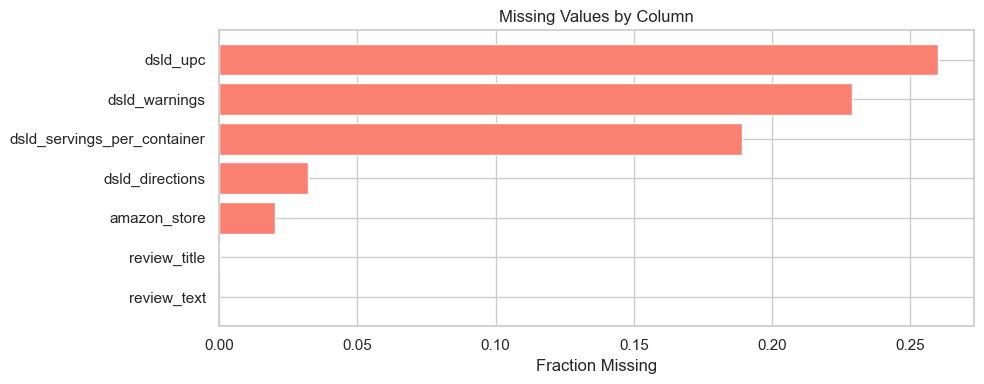

In [4]:
# Missing-value heatmap
missing = df.isnull().mean().sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ["Column", "Fraction Missing"]

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.35)))
ax.barh(missing_df["Column"], missing_df["Fraction Missing"], color="salmon")
ax.set_xlabel("Fraction Missing")
ax.set_title("Missing Values by Column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2 — Review Rating Distribution

/var/folders/c2/z_0qd_k12mz2j28_b7t7zgth0000gn/T/ipykernel_51563/1165101132.py:17: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/karinashah/miniforge3/envs/dsc80/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


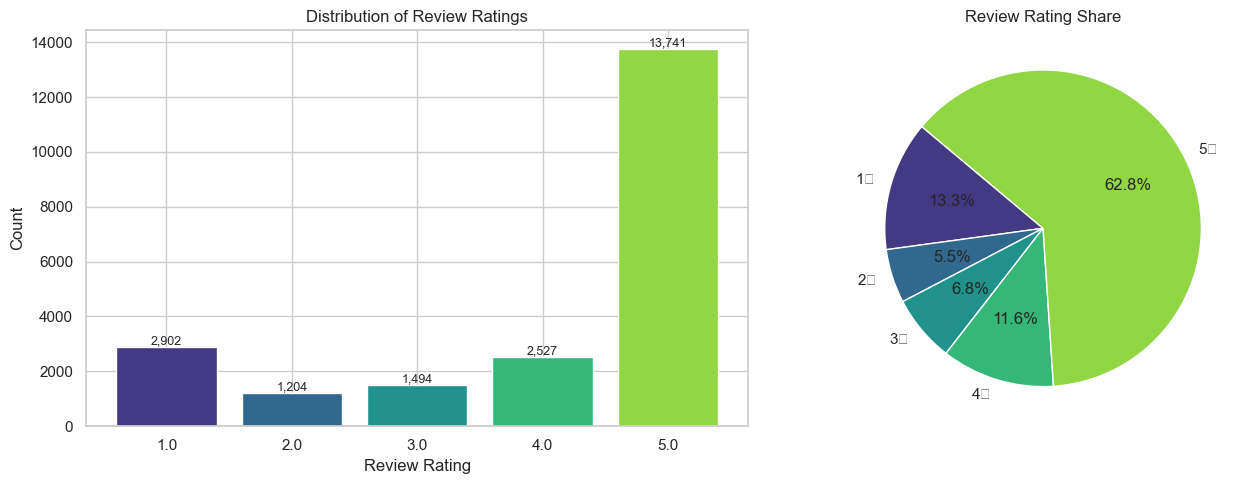

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot of review ratings
rating_counts = df["review_rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=sns.color_palette("viridis", 5))
axes[0].set_xlabel("Review Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Review Ratings")
for i, v in enumerate(rating_counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

# Pie chart
axes[1].pie(rating_counts.values, labels=[f"{r}★" for r in rating_counts.index.astype(int)],
            autopct="%1.1f%%", startangle=140, colors=sns.color_palette("viridis", 5))
axes[1].set_title("Review Rating Share")

plt.tight_layout()
plt.show()

## 3 — Top Brands & Amazon Stores

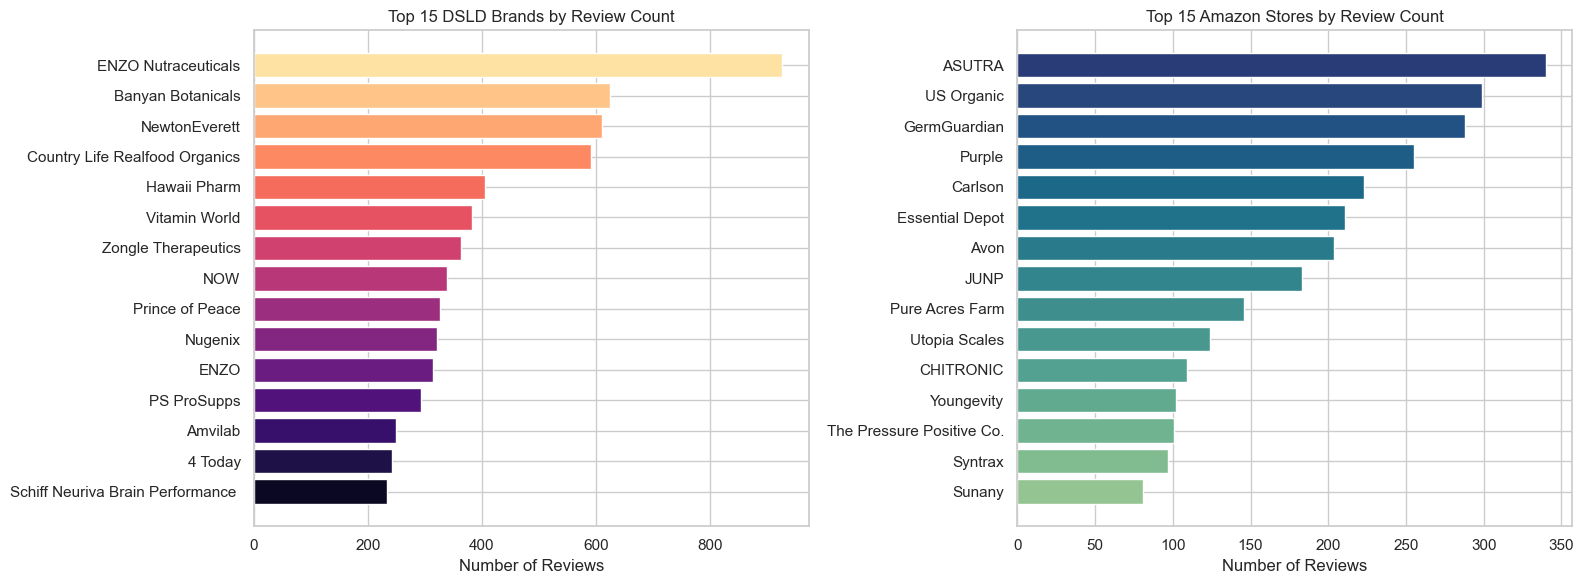

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 DSLD brand names
top_brands = df["dsld_brand_name"].value_counts().head(15)
axes[0].barh(top_brands.index[::-1], top_brands.values[::-1], color=sns.color_palette("magma", 15))
axes[0].set_xlabel("Number of Reviews")
axes[0].set_title("Top 15 DSLD Brands by Review Count")

# Top 15 Amazon stores
top_stores = df["amazon_store"].value_counts().head(15)
axes[1].barh(top_stores.index[::-1], top_stores.values[::-1], color=sns.color_palette("crest", 15))
axes[1].set_xlabel("Number of Reviews")
axes[1].set_title("Top 15 Amazon Stores by Review Count")

plt.tight_layout()
plt.show()

## 4 — Product Form & Product Type

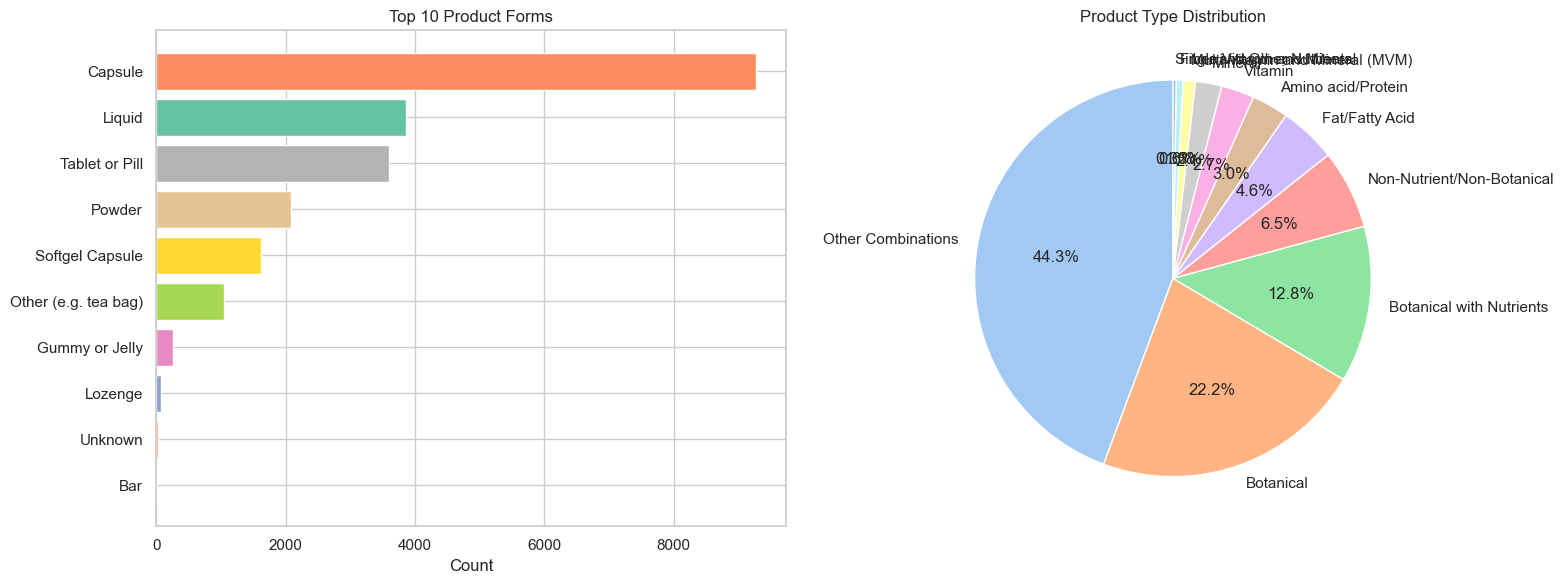

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Product form distribution
form_counts = df["dsld_form"].value_counts().head(10)
axes[0].barh(form_counts.index[::-1], form_counts.values[::-1], color=sns.color_palette("Set2", 10))
axes[0].set_xlabel("Count")
axes[0].set_title("Top 10 Product Forms")

# Product type distribution
type_counts = df["dsld_product_type"].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title("Product Type Distribution")

plt.tight_layout()
plt.show()

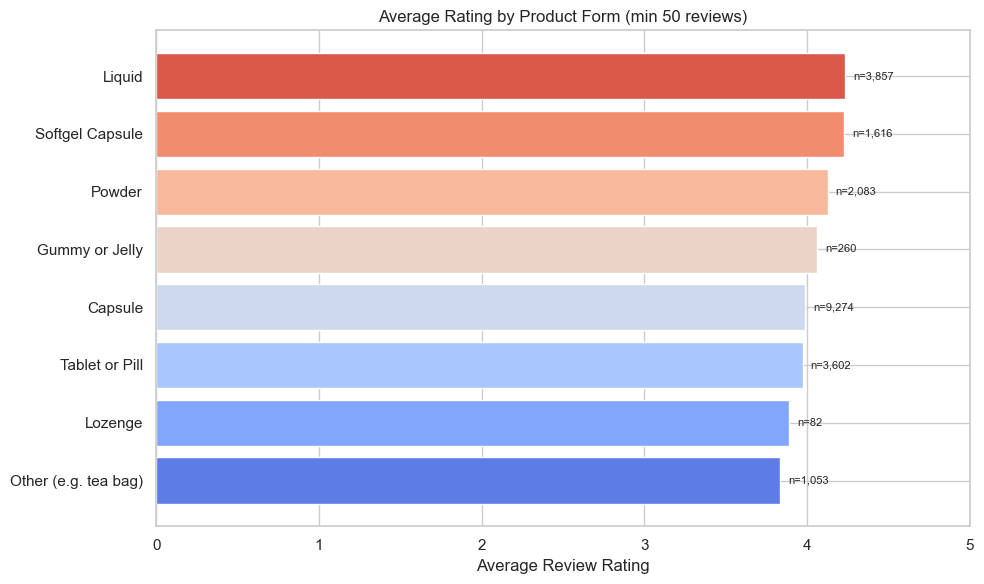

In [8]:
# Average review rating by product form
form_rating = df.groupby("dsld_form")["review_rating"].agg(["mean", "count"]).reset_index()
form_rating = form_rating[form_rating["count"] >= 50].sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(form_rating["dsld_form"], form_rating["mean"], color=sns.color_palette("coolwarm", len(form_rating)))
ax.set_xlabel("Average Review Rating")
ax.set_title("Average Rating by Product Form (min 50 reviews)")
ax.set_xlim(0, 5)
for bar, cnt in zip(bars, form_rating["count"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"n={cnt:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 5 — Ingredient Analysis

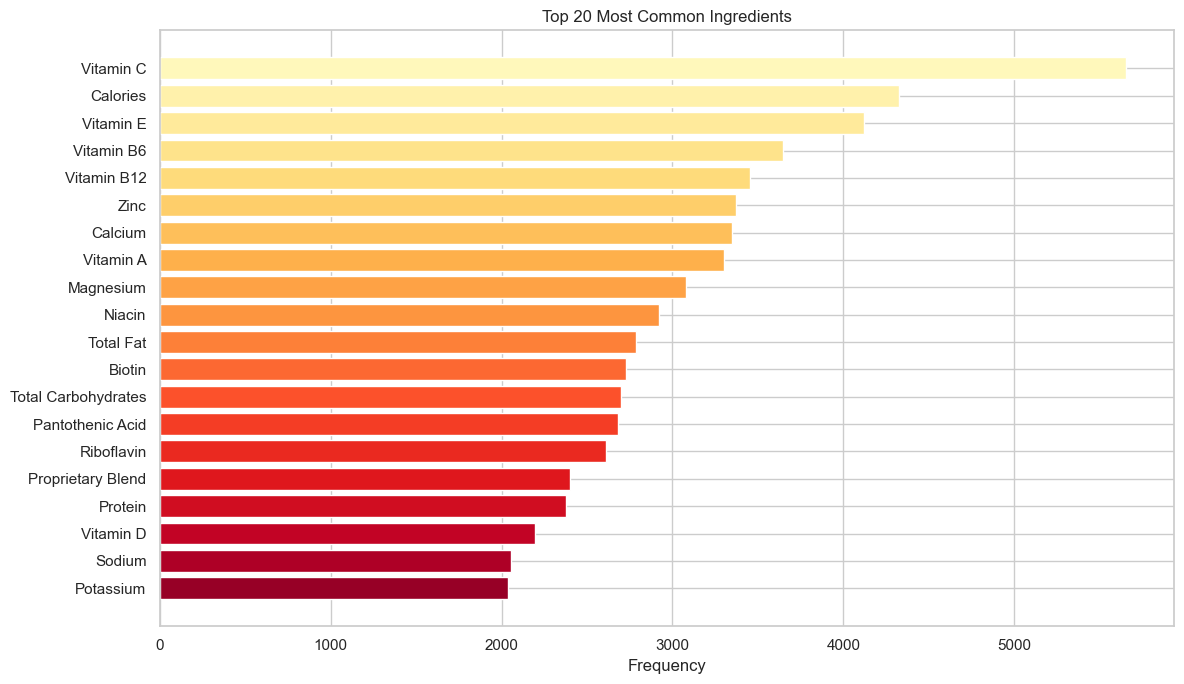

In [9]:
# Parse ingredient lists and count top ingredients
def safe_parse_list(x):
    """Safely parse a string representation of a list."""
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

ingredient_lists = df["dsld_ingredient_names"].apply(safe_parse_list)
all_ingredients = [ing.strip() for sublist in ingredient_lists for ing in sublist]
ingredient_freq = Counter(all_ingredients).most_common(20)

fig, ax = plt.subplots(figsize=(12, 7))
names, counts = zip(*ingredient_freq)
ax.barh(list(names)[::-1], list(counts)[::-1], color=sns.color_palette("YlOrRd_r", 20))
ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Common Ingredients")
plt.tight_layout()
plt.show()

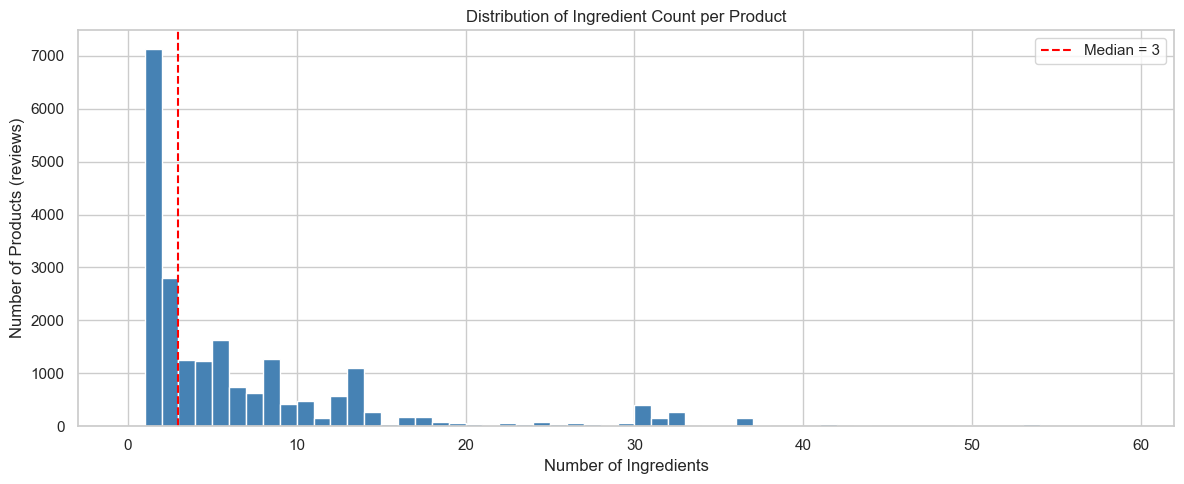

In [10]:
# Distribution of ingredient count per product
fig, ax = plt.subplots(figsize=(12, 5))
ing_counts = df["dsld_ingredient_count"].dropna()
ax.hist(ing_counts, bins=range(0, int(ing_counts.max()) + 2), color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Ingredients")
ax.set_ylabel("Number of Products (reviews)")
ax.set_title("Distribution of Ingredient Count per Product")
ax.axvline(ing_counts.median(), color="red", linestyle="--", label=f"Median = {ing_counts.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## 6 — Verified Purchase & Helpful Votes

/var/folders/c2/z_0qd_k12mz2j28_b7t7zgth0000gn/T/ipykernel_51563/3950212140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="verified_purchase", y="review_rating", data=df, palette="Set2", ax=axes[0])


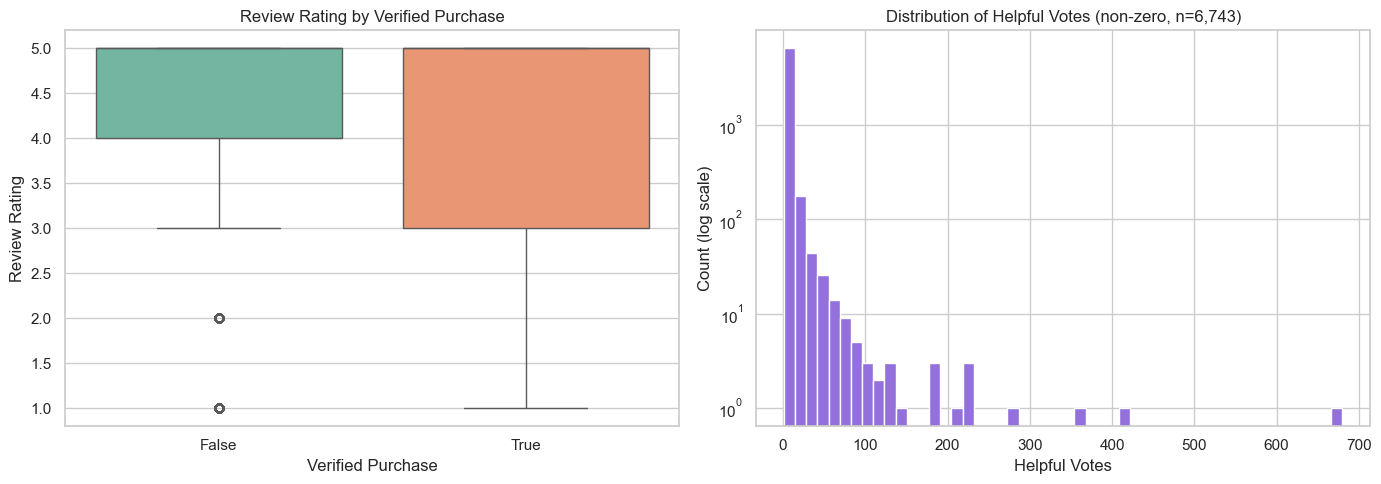

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution by verified vs non-verified purchase
sns.boxplot(x="verified_purchase", y="review_rating", data=df, palette="Set2", ax=axes[0])
axes[0].set_title("Review Rating by Verified Purchase")
axes[0].set_xlabel("Verified Purchase")
axes[0].set_ylabel("Review Rating")

# Helpful votes distribution (log scale for visibility)
helpful = df["helpful_vote"].dropna()
helpful_nonzero = helpful[helpful > 0]
axes[1].hist(helpful_nonzero, bins=50, color="mediumpurple", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xlabel("Helpful Votes")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title(f"Distribution of Helpful Votes (non-zero, n={len(helpful_nonzero):,})")

plt.tight_layout()
plt.show()

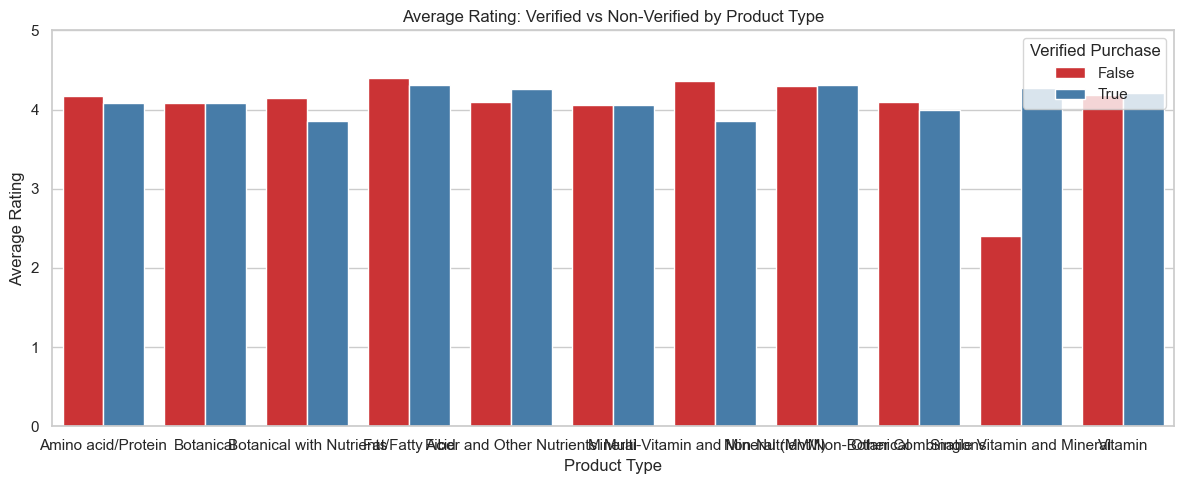

In [12]:
# Average rating: verified vs non-verified, by product type
vp_type = df.groupby(["dsld_product_type", "verified_purchase"])["review_rating"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=vp_type, x="dsld_product_type", y="review_rating", hue="verified_purchase",
            palette="Set1", ax=ax)
ax.set_title("Average Rating: Verified vs Non-Verified by Product Type")
ax.set_xlabel("Product Type")
ax.set_ylabel("Average Rating")
ax.set_ylim(0, 5)
ax.legend(title="Verified Purchase")
plt.tight_layout()
plt.show()

## 7 — Reviews Over Time

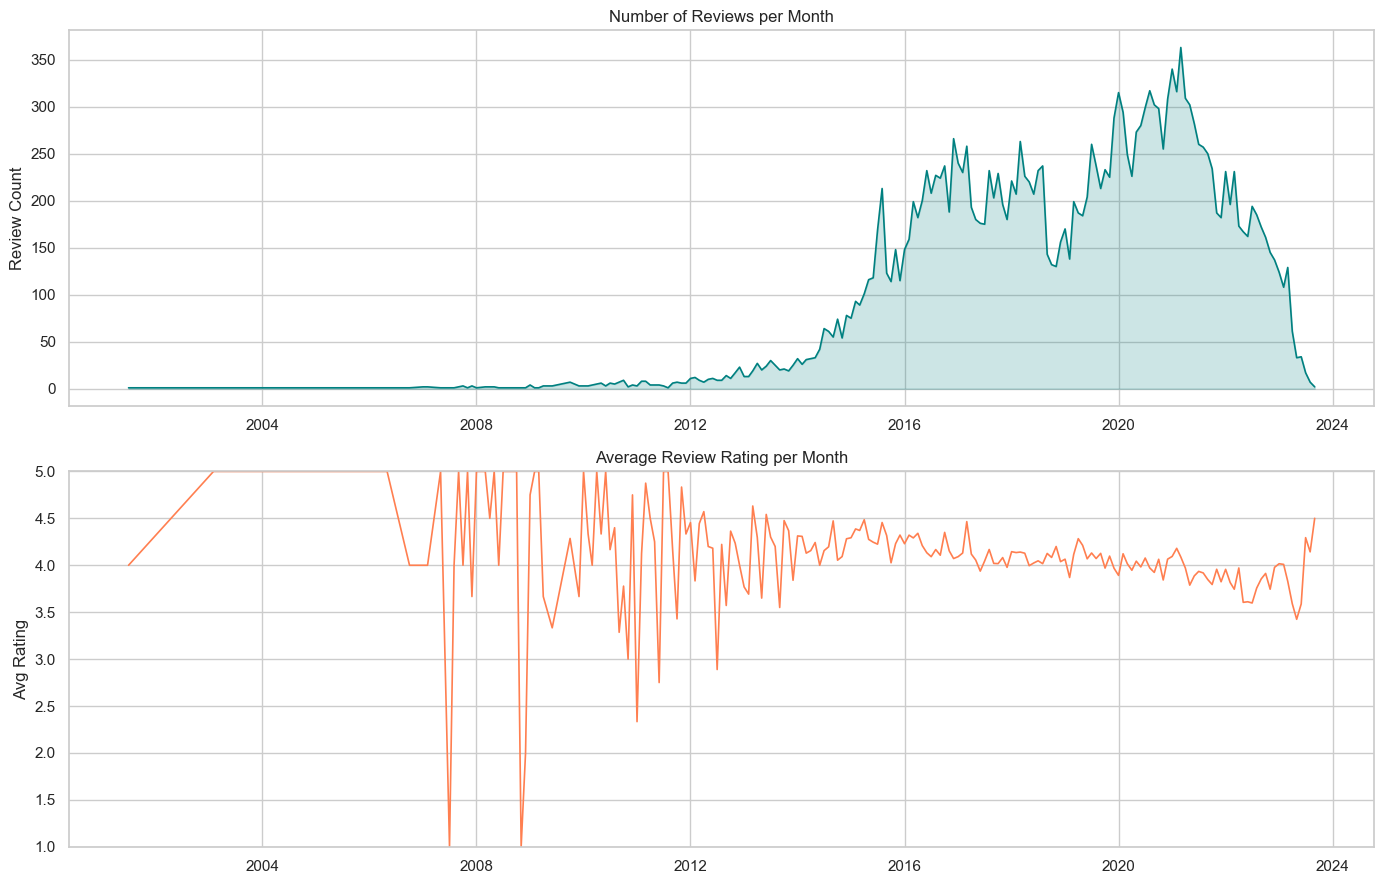

In [13]:
# Convert timestamp (milliseconds) to datetime
df["review_date"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")
df["review_year"] = df["review_date"].dt.year
df["review_month"] = df["review_date"].dt.to_period("M")

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Reviews per month
monthly = df.groupby("review_month").size()
monthly.index = monthly.index.to_timestamp()
axes[0].plot(monthly.index, monthly.values, color="teal", linewidth=1.2)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.2, color="teal")
axes[0].set_title("Number of Reviews per Month")
axes[0].set_ylabel("Review Count")

# Average rating per month
monthly_rating = df.groupby("review_month")["review_rating"].mean()
monthly_rating.index = monthly_rating.index.to_timestamp()
axes[1].plot(monthly_rating.index, monthly_rating.values, color="coral", linewidth=1.2)
axes[1].set_title("Average Review Rating per Month")
axes[1].set_ylabel("Avg Rating")
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.show()

## 8 — Target Groups & Claims

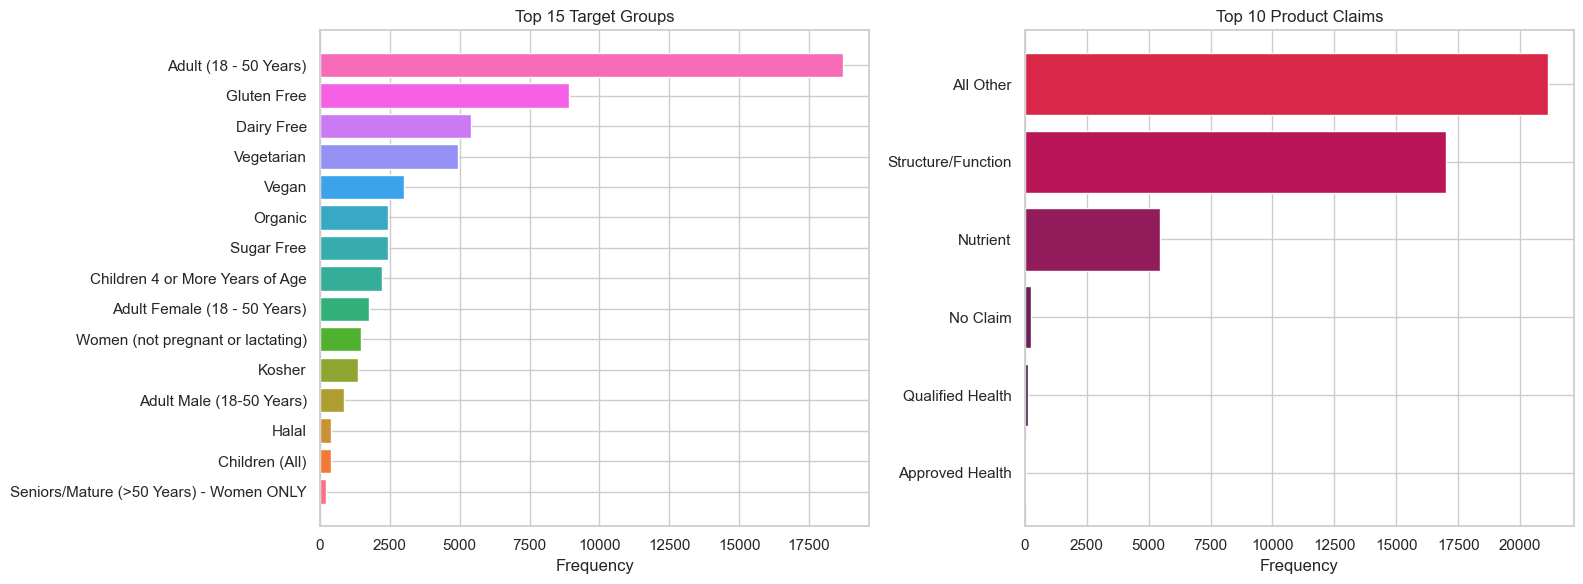

In [14]:
# Top target groups
target_lists = df["dsld_target_groups"].apply(safe_parse_list)
all_targets = [t.strip() for sublist in target_lists for t in sublist]
target_freq = Counter(all_targets).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tgt_names, tgt_counts = zip(*target_freq)
axes[0].barh(list(tgt_names)[::-1], list(tgt_counts)[::-1], color=sns.color_palette("husl", 15))
axes[0].set_xlabel("Frequency")
axes[0].set_title("Top 15 Target Groups")

# Top claims
claim_lists = df["dsld_claims"].apply(safe_parse_list)
all_claims = [c.strip() for sublist in claim_lists for c in sublist]
claim_freq = Counter(all_claims).most_common(10)

clm_names, clm_counts = zip(*claim_freq)
axes[1].barh(list(clm_names)[::-1], list(clm_counts)[::-1], color=sns.color_palette("rocket", 10))
axes[1].set_xlabel("Frequency")
axes[1].set_title("Top 10 Product Claims")

plt.tight_layout()
plt.show()

## 9 — Correlation Heatmap & Numeric Summary

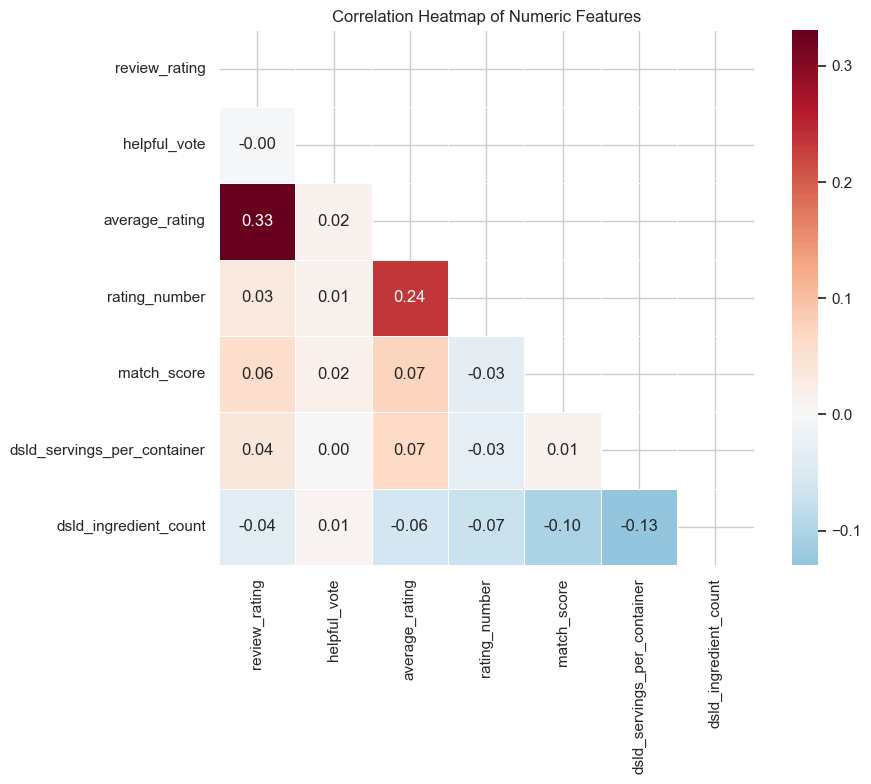

In [15]:
# Correlation heatmap of numeric columns
numeric_cols = ["review_rating", "helpful_vote", "average_rating", "rating_number",
                "match_score", "dsld_servings_per_container", "dsld_ingredient_count"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

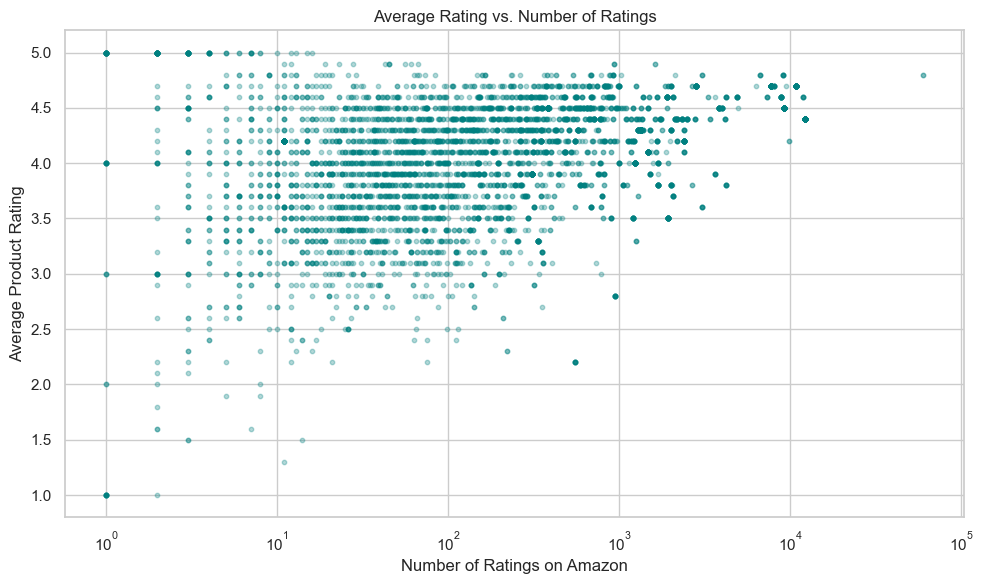


✅ EDA complete! All charts use a 10% random sample of the full dataset.


In [16]:
# Scatter: average product rating vs number of ratings
fig, ax = plt.subplots(figsize=(10, 6))
sample_scatter = df.dropna(subset=["average_rating", "rating_number"]).sample(min(5000, len(df)), random_state=SEED)
ax.scatter(sample_scatter["rating_number"], sample_scatter["average_rating"],
           alpha=0.3, s=10, color="teal")
ax.set_xlabel("Number of Ratings on Amazon")
ax.set_ylabel("Average Product Rating")
ax.set_title("Average Rating vs. Number of Ratings")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

print("\n✅ EDA complete! All charts use a 10% random sample of the full dataset.")

## 10 — XGBoost: Label Features → Average Rating

**Hypothesis:** There is a relationship between label features (ingredient names, number of ingredients, brand name) and the average Amazon rating of a product.

Liyun tested this with a CNN (R² ≈ 0, MAE 0.504 vs naive baseline 0.509). Here we test the same hypothesis with **XGBoost**, a gradient-boosted tree ensemble that can capture non-linear interactions between features without embedding layers, making it a strong complementary test.

**Approach:**
1. Deduplicate to **product-level** rows (one per `parent_asin`, since `average_rating` is constant per product).
2. Engineer features from **label data only**: ingredient names (multi-hot encoded), ingredient count, brand (label-encoded), product form, and product type.
3. Train an XGBoost regressor predicting `average_rating`.
4. Compare MAE / RMSE / R² against the CNN and a naive predict-the-mean baseline.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- reload full dataset & deduplicate to product level ----------
df_model = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset: {df_model.shape[0]:,} rows")

df_prod = df_model.drop_duplicates(subset=["parent_asin"], keep="first").reset_index(drop=True)
print(f"Unique products after dedup: {len(df_prod):,}")
print(f"average_rating — min: {df_prod['average_rating'].min():.1f}, "
      f"max: {df_prod['average_rating'].max():.1f}, "
      f"mean: {df_prod['average_rating'].mean():.3f}, "
      f"std: {df_prod['average_rating'].std():.3f}")

# ---------- feature engineering (label features only) ----------

def parse_ingredient_list(raw):
    """Parse stringified Python list into a list of lowercase ingredient names."""
    if pd.isna(raw) or raw == "":
        return []
    try:
        v = ast.literal_eval(str(raw).strip())
        if isinstance(v, (list, tuple)):
            return [str(x).strip().lower() for x in v if str(x).strip()]
    except (ValueError, SyntaxError):
        pass
    return [str(raw).strip().lower()]

df_prod["_ingredients"] = df_prod["dsld_ingredient_names"].apply(parse_ingredient_list)

# Multi-hot encode the 50 most common ingredients
all_ingredients = [ing for sublist in df_prod["_ingredients"] for ing in sublist]
ing_counter = Counter(all_ingredients)
top_ingredients = [ing for ing, _ in ing_counter.most_common(50)]

coverage = sum(ing_counter[i] for i in top_ingredients) / max(len(all_ingredients), 1)
print(f"\nTop 50 ingredients cover {coverage:.0%} of all ingredient mentions")

ingredient_cols = []
for ing in top_ingredients:
    col = "ing_" + ing.replace(" ", "_").replace("-", "_").replace(",", "")[:30]
    df_prod[col] = df_prod["_ingredients"].apply(lambda x, i=ing: int(i in x))
    ingredient_cols.append(col)

# Label-encode categoricals
le_brand = LabelEncoder()
df_prod["brand_enc"] = le_brand.fit_transform(df_prod["dsld_brand_name"].fillna("unknown"))

le_form = LabelEncoder()
df_prod["form_enc"] = le_form.fit_transform(df_prod["dsld_form"].fillna("unknown"))

le_type = LabelEncoder()
df_prod["type_enc"] = le_type.fit_transform(df_prod["dsld_product_type"].fillna("unknown"))

df_prod["dsld_ingredient_count"] = pd.to_numeric(
    df_prod["dsld_ingredient_count"], errors="coerce"
).fillna(0)

# ---------- assemble feature matrix (label features only) ----------
label_feature_cols = (
    ["dsld_ingredient_count", "brand_enc", "form_enc", "type_enc"]
    + ingredient_cols
)

X = df_prod[label_feature_cols].copy()
y = df_prod["average_rating"].copy()

mask = y.notna()
X, y = X[mask], y[mask]

print(f"\nLabel features: {len(label_feature_cols)} total")
print(f"  • dsld_ingredient_count  (1 numeric)")
print(f"  • brand_enc              ({df_prod['brand_enc'].nunique()} unique brands)")
print(f"  • form_enc               ({df_prod['form_enc'].nunique()} forms)")
print(f"  • type_enc               ({df_prod['type_enc'].nunique()} types)")
print(f"  • {len(ingredient_cols)} multi-hot ingredient indicators")
print(f"\nProducts for modelling: {len(X):,}")

Full dataset: 218,678 rows
Unique products after dedup: 24,017
average_rating — min: 1.0, max: 5.0, mean: 3.954, std: 0.795

Top 50 ingredients cover 67% of all ingredient mentions

Label features: 54 total
  • dsld_ingredient_count  (1 numeric)
  • brand_enc              (1684 unique brands)
  • form_enc               (10 forms)
  • type_enc               (11 types)
  • 50 multi-hot ingredient indicators

Products for modelling: 24,017


In [18]:
# ── Train / test split (80/20, same as CNN pipeline) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── Naive baseline: always predict the training-set mean ──
naive_pred = np.full(len(y_test), y_train.mean())
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print(f"\nNaive baseline (predict mean = {y_train.mean():.3f}):")
print(f"  MAE:  {naive_mae:.4f}")
print(f"  RMSE: {naive_rmse:.4f}")

# ── XGBoost Regressor ──
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=5.0,
    min_child_weight=5,
    random_state=SEED,
    tree_method="hist",
    n_jobs=-1,
)
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

y_pred = xgb_reg.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

# ── 5-fold cross-validation for robust estimate ──
cv_mae = cross_val_score(xgb_reg, X, y, cv=5, scoring="neg_mean_absolute_error")
cv_r2 = cross_val_score(xgb_reg, X, y, cv=5, scoring="r2")

print(f"\nXGBoost (label features only):")
print(f"  MAE:  {xgb_mae:.4f}")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  R²:   {xgb_r2:.4f}")
print(f"  5-fold CV MAE: {-cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"  5-fold CV R²:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# ── Comparison table ──
print(f"\n{'='*65}")
print(f"{'Model':<40} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print(f"{'-'*65}")
print(f"{'Naive baseline (predict mean)':<40} {naive_mae:>7.3f} {naive_rmse:>7.3f} {'0.000':>7}")
print(f"{'CNN  (Liyun, 10K sample, 1395 prods)':<40} {'0.504':>7} {'0.707':>7} {'-0.025':>7}")
print(f"{'XGBoost (label feats, {0} prods)'.format(len(X)):<40} {xgb_mae:>7.3f} {xgb_rmse:>7.3f} {xgb_r2:>7.3f}")
print(f"{'='*65}")

Train: 19,213  |  Test: 4,804

Naive baseline (predict mean = 3.956):
  MAE:  0.6034
  RMSE: 0.7946
[0]	validation_0-rmse:0.79418
[50]	validation_0-rmse:0.78604
[100]	validation_0-rmse:0.78461
[150]	validation_0-rmse:0.78382
[200]	validation_0-rmse:0.78325
[250]	validation_0-rmse:0.78294
[299]	validation_0-rmse:0.78285

XGBoost (label features only):
  MAE:  0.5862
  RMSE: 0.7828
  R²:   0.0291
  5-fold CV MAE: 0.5883 ± 0.1060
  5-fold CV R²:  0.0343 ± 0.0070

Model                                        MAE    RMSE      R²
-----------------------------------------------------------------
Naive baseline (predict mean)              0.603   0.795   0.000
CNN  (Liyun, 10K sample, 1395 prods)       0.504   0.707  -0.025
XGBoost (label feats, 24017 prods)         0.586   0.783   0.029


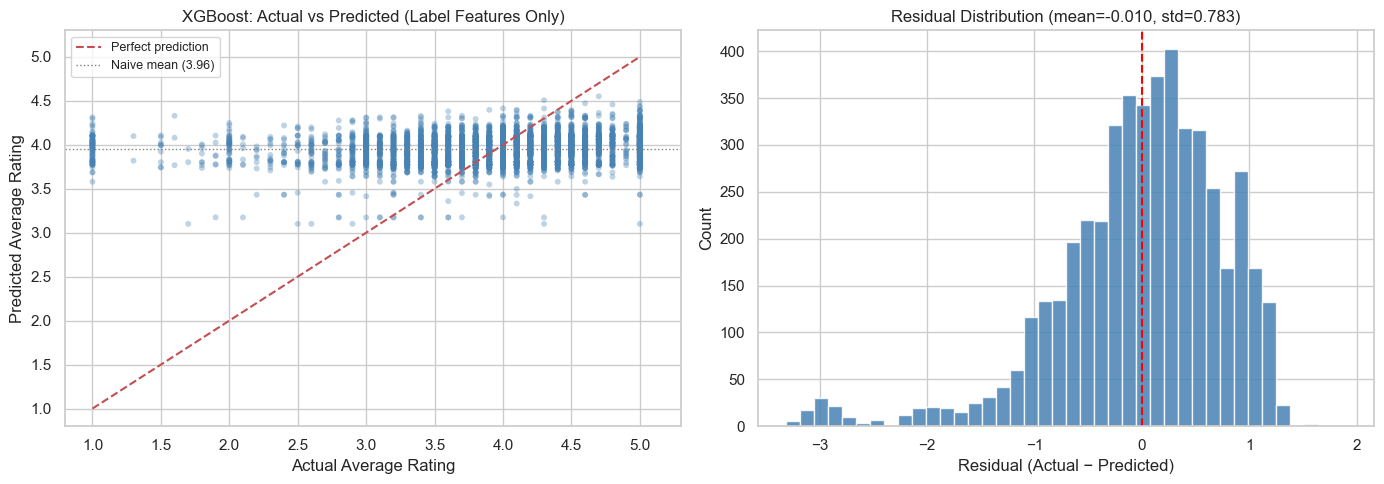

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.35, s=18, color="steelblue", edgecolors="none")
ax.plot([1, 5], [1, 5], "r--", lw=1.5, label="Perfect prediction")
ax.axhline(y_train.mean(), color="gray", ls=":", lw=1, label=f"Naive mean ({y_train.mean():.2f})")
ax.set_xlabel("Actual Average Rating")
ax.set_ylabel("Predicted Average Rating")
ax.set_title("XGBoost: Actual vs Predicted (Label Features Only)")
ax.legend(fontsize=9)
ax.set_xlim(0.8, 5.3)
ax.set_ylim(0.8, 5.3)

# Residual distribution
ax = axes[1]
residuals = y_test.values - y_pred
ax.hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", ls="--", lw=1.5)
ax.set_xlabel("Residual (Actual − Predicted)")
ax.set_ylabel("Count")
ax.set_title(f"Residual Distribution (mean={residuals.mean():.3f}, std={residuals.std():.3f})")

plt.tight_layout()
plt.show()

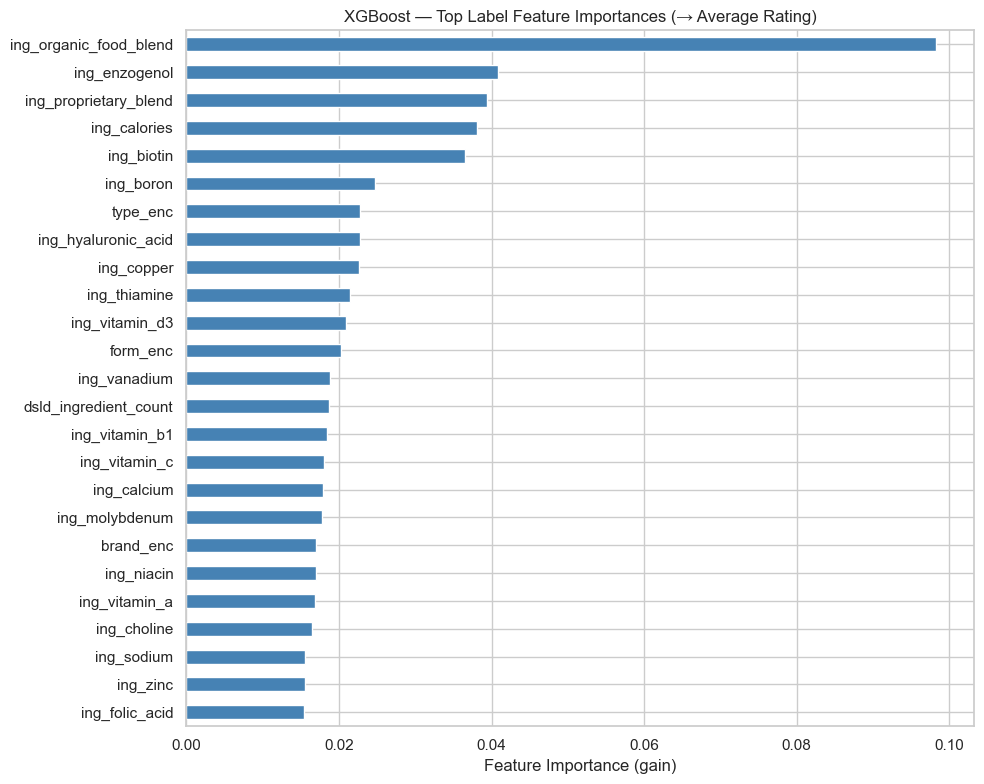

Top 10 most important label features:
  ing_organic_food_blend              0.0983
  ing_enzogenol                       0.0408
  ing_proprietary_blend               0.0394
  ing_calories                        0.0381
  ing_biotin                          0.0366
  ing_boron                           0.0247
  type_enc                            0.0227
  ing_hyaluronic_acid                 0.0227
  ing_copper                          0.0227
  ing_thiamine                        0.0214


In [20]:
# ── Feature importance (gain) ──
importances = pd.Series(
    xgb_reg.feature_importances_, index=label_feature_cols
).sort_values(ascending=True)

top_n = min(25, len(importances))
fig, ax = plt.subplots(figsize=(10, 8))
importances.tail(top_n).plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost — Top Label Feature Importances (→ Average Rating)")
plt.tight_layout()
plt.show()

print("Top 10 most important label features:")
for feat, imp in importances.iloc[-10:][::-1].items():
    print(f"  {feat:35s} {imp:.4f}")

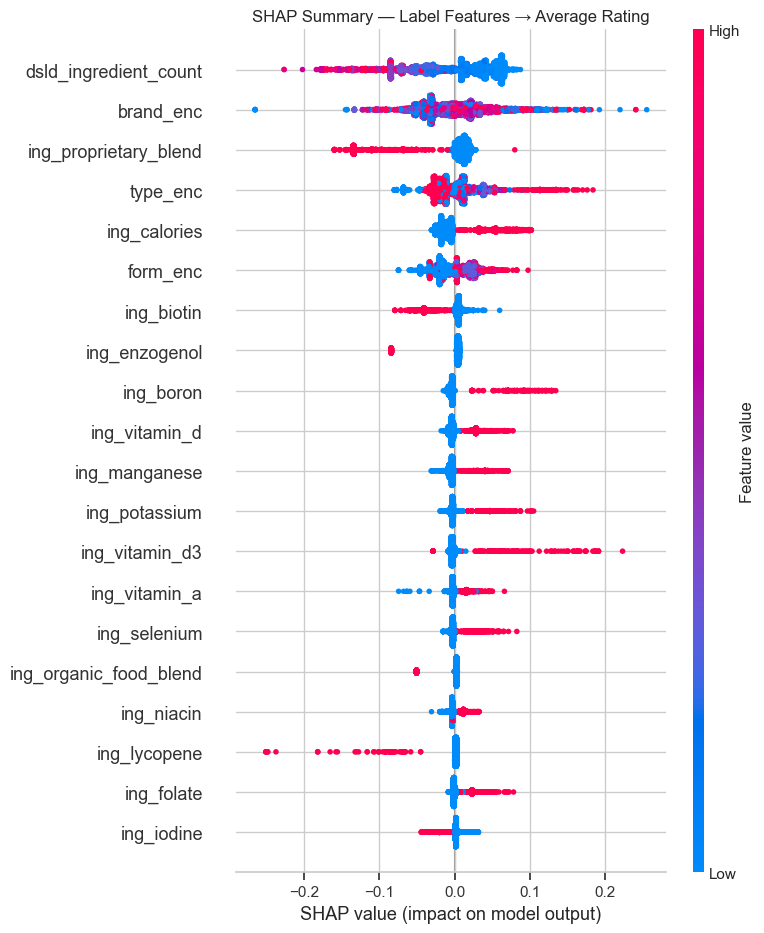

In [21]:
# ── SHAP values ──
try:
    import shap
    explainer = shap.TreeExplainer(xgb_reg)
    shap_values = explainer.shap_values(X_test)

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, feature_names=label_feature_cols,
                      max_display=20, show=False)
    plt.title("SHAP Summary — Label Features → Average Rating", fontsize=12)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install shap (`pip install shap`) for SHAP-based feature analysis.")
except Exception as e:
    print(f"SHAP computation skipped: {e}")

In [22]:
# ── Ablation: predictive power of each feature group alone ──
feature_groups = {
    "Ingredient count only":            ["dsld_ingredient_count"],
    "Brand only":                       ["brand_enc"],
    "Product form only":                ["form_enc"],
    "Product type only":                ["type_enc"],
    "Top-50 ingredients (multi-hot)":   ingredient_cols,
    "Brand + ingredient count":         ["brand_enc", "dsld_ingredient_count"],
    "All label features combined":      label_feature_cols,
}

print(f"{'Feature Group':<40} {'CV MAE':>8} {'CV R²':>8}")
print("-" * 60)

for name, cols in feature_groups.items():
    Xg = df_prod.loc[mask, cols]
    tmp = XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=5.0, min_child_weight=5,
        random_state=SEED, tree_method="hist", n_jobs=-1, verbosity=0,
    )
    cv_m = cross_val_score(tmp, Xg, y, cv=5, scoring="neg_mean_absolute_error")
    cv_r = cross_val_score(tmp, Xg, y, cv=5, scoring="r2")
    print(f"  {name:<38} {-cv_m.mean():>7.4f} {cv_r.mean():>8.4f}")

print(f"\n  {'Naive baseline (predict mean)':<38} {naive_mae:>7.4f} {'0.0000':>8}")
print("\nNo individual feature group substantially outperforms the naive baseline.")

Feature Group                              CV MAE    CV R²
------------------------------------------------------------
  Ingredient count only                   0.6030   0.0049
  Brand only                              0.5967   0.0173
  Product form only                       0.6035   0.0041
  Product type only                       0.6036   0.0048
  Top-50 ingredients (multi-hot)          0.5945   0.0213
  Brand + ingredient count                0.5971   0.0174
  All label features combined             0.5895   0.0332

  Naive baseline (predict mean)           0.6034   0.0000

No individual feature group substantially outperforms the naive baseline.


In [23]:
import json
from pathlib import Path

output_dir = Path("results/xgboost_regression")
output_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    "mae": float(xgb_mae),
    "rmse": float(xgb_rmse),
    "r2": float(xgb_r2),
    "naive_mean_baseline_mae": float(naive_mae),
    "cv_mae_mean": float(-cv_mae.mean()),
    "cv_mae_std": float(cv_mae.std()),
    "cv_r2_mean": float(cv_r2.mean()),
    "n_products": int(len(X)),
    "n_features": int(len(label_feature_cols)),
}

with open(output_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame({"actual": y_test.values, "predicted": y_pred}).to_csv(
    output_dir / "val_predictions.csv", index=False
)

pd.Series(xgb_reg.feature_importances_, index=label_feature_cols).sort_values(
    ascending=False
).to_csv(output_dir / "feature_importances.csv")

print("Results saved to results/xgboost_regression/")
print(f"  • metrics.json            (MAE, RMSE, R², CV scores)")
print(f"  • val_predictions.csv     (actual vs predicted for test set)")
print(f"  • feature_importances.csv (all feature importances)")
print(f"\n{'='*65}")
print("CONCLUSION")
print(f"{'='*65}")
print(f"XGBoost with label-only features achieves MAE = {xgb_mae:.3f}")
print(f"(naive baseline MAE = {naive_mae:.3f}, CNN MAE = 0.504)")
print(f"R² = {xgb_r2:.3f}")
print(f"\nBoth tree-based (XGBoost) and neural (CNN) models confirm that")
print(f"label features alone — ingredients, ingredient count, brand —")
print(f"have near-zero predictive power for average Amazon ratings.")
print(f"Consumer ratings are driven by factors beyond label content.")

Results saved to results/xgboost_regression/
  • metrics.json            (MAE, RMSE, R², CV scores)
  • val_predictions.csv     (actual vs predicted for test set)
  • feature_importances.csv (all feature importances)

CONCLUSION
XGBoost with label-only features achieves MAE = 0.586
(naive baseline MAE = 0.603, CNN MAE = 0.504)
R² = 0.029

Both tree-based (XGBoost) and neural (CNN) models confirm that
label features alone — ingredients, ingredient count, brand —
have near-zero predictive power for average Amazon ratings.
Consumer ratings are driven by factors beyond label content.
